In [15]:
import numpy as np
from sklearn import decomposition 
x = np.array([[2,6],[1,7]])
print('origial matrix')
print(x)
print('original shape :',x.shape)
pca = decomposition.PCA(n_components = 2)
x_pca  = pca.fit_transform(x)
print('transformed Matrix')
print(x_pca)
print('transformed shape',x_pca.shape)
x_new = pca.inverse_transform(x_pca)
print(x_new)
print('after inverse_transform')
print('explained variance')
print(pca.explained_variance_ratio_)
print('completed\n\n')
print('singular values')
print(pca.singular_values_)
print('completed\n\n')

origial matrix
[[2 6]
 [1 7]]
original shape : (2, 2)
transformed Matrix
[[ 7.07106781e-01 -1.18606713e-17]
 [-7.07106781e-01 -1.18606713e-17]]
transformed shape (2, 2)
[[2. 6.]
 [1. 7.]]
after inverse_transform
explained variance
[1.00000000e+00 2.81351049e-34]
completed


singular values
[1.00000000e+00 1.67735223e-17]
completed




In [21]:
import numpy as np
from numpy.linalg import eig
x = np.array([[3,6],[4,7]])
print('original matrix')
print(x)
print(x.shape)

m = np.mean(x.T,axis = 1)
print('mean matrix')
print(m)
c = x - m
print('center matrix')
print(c)

v = np.cov(c.T)
print('covariance of the matrix')
print(v)

values,vectors = eig(v)
print('eigen vector')
print(vectors)
print('eigen values:',values)



original matrix
[[3 6]
 [4 7]]
(2, 2)
mean matrix
[3.5 6.5]
center matrix
[[-0.5 -0.5]
 [ 0.5  0.5]]
covariance of the matrix
[[0.5 0.5]
 [0.5 0.5]]
eigen vector
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
eigen values: [1.00000000e+00 1.11022302e-16]


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn import decomposition
import seaborn as sns

df = pd.read_csv("iris.csv")
print(df.head(10)) 
array = df.values
X = array[:,0:4]
y = array[:,4]

kfold = KFold(n_splits=10) 
model = KNeighborsClassifier(n_neighbors=3)
score = cross_val_score(model,X,y,cv=10)
print('\n\n')
print("Cross score before applying PCA\n")
print(score.mean())

print("Apply PCA now...")

pca = decomposition.PCA(n_components=1)
X_pca = pca.fit_transform(X)
core = cross_val_score(model,X_pca,y,cv=10)
print('\n\n')
print("Cross score After applying PCA\n")
print(score.mean())


   sepal.length  sepal.width  petal.length  petal.width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa
5           5.4          3.9           1.7          0.4  Setosa
6           4.6          3.4           1.4          0.3  Setosa
7           5.0          3.4           1.5          0.2  Setosa
8           4.4          2.9           1.4          0.2  Setosa
9           4.9          3.1           1.5          0.1  Setosa



Cross score before applying PCA

1.0
Apply PCA now...



Cross score After applying PCA

1.0


Intercept: 
 0.5400000000000005
Coefficients: 
 [0.66]

The Regression Equation is [0.66] * X+ 0.5400000000000005

Adjusted R Squared for Regression model: 0.9972527472527473


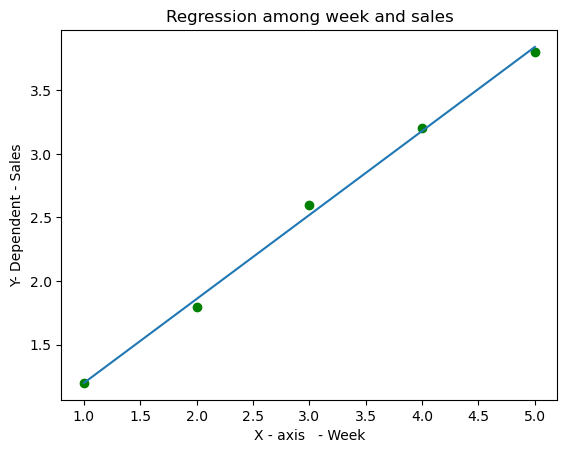

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn import linear_model

salesdata = {'week': [1,2,3,4,5],
                'sales': [1.2,1.8,2.6,3.2,3.8]        
                }

df = pd.DataFrame(salesdata,columns=['week','sales']) 


plt.scatter(df['week'], df['sales'], color='green')
plt.title('Regression among week and sales')
plt.xlabel('X - axis   - Week')
plt.ylabel('Y- Dependent - Sales')


week = df['week'].values.reshape(1,-1)
sales = df['sales'].values.reshape(1,-1)

X = df[['week']] 
y = df['sales']

regr = linear_model.LinearRegression()
regr.fit(X,y)

print('Intercept: \n', regr.intercept_)
print('Coefficients: \n', regr.coef_)

print('\nThe Regression Equation is',regr.coef_,'* X+',regr.intercept_)

pred = regr.predict(X) 
plt.plot(X,pred)    
print("\nAdjusted R Squared for Regression model:",regr.score(X,y))


Intercept: 
 -0.02674636665726826
Coefficients: 
 [28.04215347]

The Regression Equation is [28.04215347] * X + -0.02674636665726826

Adjusted R Squared for Regression model: 0.9999905316910326


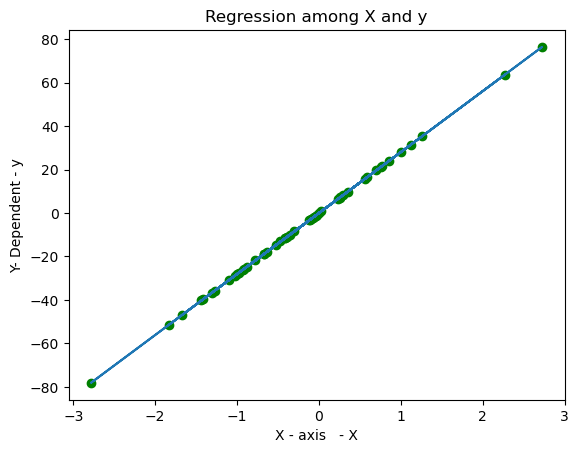

In [3]:
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.datasets import make_regression

X,y = make_regression(n_samples = 50,n_features=1,noise=0.1)

plt.scatter(X,y,color='green')
plt.title('Regression among X and y')
plt.xlabel('X - axis   - X')
plt.ylabel('Y- Dependent - y')

regr = linear_model.LinearRegression()
regr.fit(X,y)

print('Intercept: \n', regr.intercept_)
print('Coefficients: \n', regr.coef_)
print('\nThe Regression Equation is',regr.coef_,'* X +',regr.intercept_)
pred = regr.predict(X) 
plt.plot(X,pred)    
print("\nAdjusted R Squared for Regression model:",regr.score(X,y))
